# Feature Importances Analyse

* For interpretability of the prediction
* Tree Modelle Feature Importances
* Permutation Feature Importances Ranking

In [1]:
# feature importances analysis of tree model
import sys
import os
import pickle
import importlib
import numpy as np
import pandas as pd

# Add the src directory to the system path to allow importing custom modules
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

from train_model_predict import (plot_learning_curve, print_scores,
                                 save_model_to_pickle, train_test_split_by_date,
                                 tune_model_bayesian)
from walk_forward import predict_date_range_in_memory

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})


* Conclusion: 
    - Three models identify similar features as important 
    - Energy load lag features and rolling statistics of the target variable are consistently ranked as top predictors across all three models
    - This suggests that past values and trends in electricity load are key predictors for future demand.   


In [2]:
from etl import update_database, get_connection, load_combined_data

# retrieve data and models
import pandas as pd
from train_model_predict import load_model_from_pickle, train_test_split_by_date

# Ensure the database is up to date — no-op if already current
update_database()

# Load the pre-joined, feature-engineered dataset from the DB view
conn = get_connection()
df_raw = load_combined_data(conn)
conn.close()

# Drop non-predictive columns; rename target to match existing pipeline conventions
df_for_modeling = (
    df_raw
    .drop(columns=['smard_forecast_mwh', 'data_source'], errors='ignore')
    .rename(columns={'energy_demand_mwh': 'EnergyDemand'})
    .dropna()
    .reset_index(drop=True)
)

features_train, target_train, features_test, target_test = train_test_split_by_date(df_for_modeling, 
                                                                                    date_column='time',
                                                                                    target_column='EnergyDemand', 
                                                                                    split_date='2025-10-01')
best_lgbm_model_bayesian = load_model_from_pickle('../models/best_lgbm_model_bayesian_etl.pkl')
best_xgb_model_bayesian = load_model_from_pickle('../models/best_xgb_model_bayesian_etl.pkl')


Database ready: c:\Projects\DataScience\Portfolio\energy_demand_forecast\workspace_energy_demand\db\energy_demand.db

Current data status:
  energy         :  65848 rows | max: 2026-07-13T23:00:00+0200 | up-to-date: False
  weather        :  66001 rows | max: 2026-07-14T01:00:00+0200 | up-to-date: True

[Energy] Filling gap...
Updating energy data (2026-07-14 → 2026-07-14)...
Inserted 24 new rows into energy_demand.

[Weather] Up to date — nothing to do.

Done.
  energy_demand : 65872 rows | max: 2026-07-14T23:00:00+0200
  weather       : 66001 rows | max: 2026-07-14T01:00:00+0200


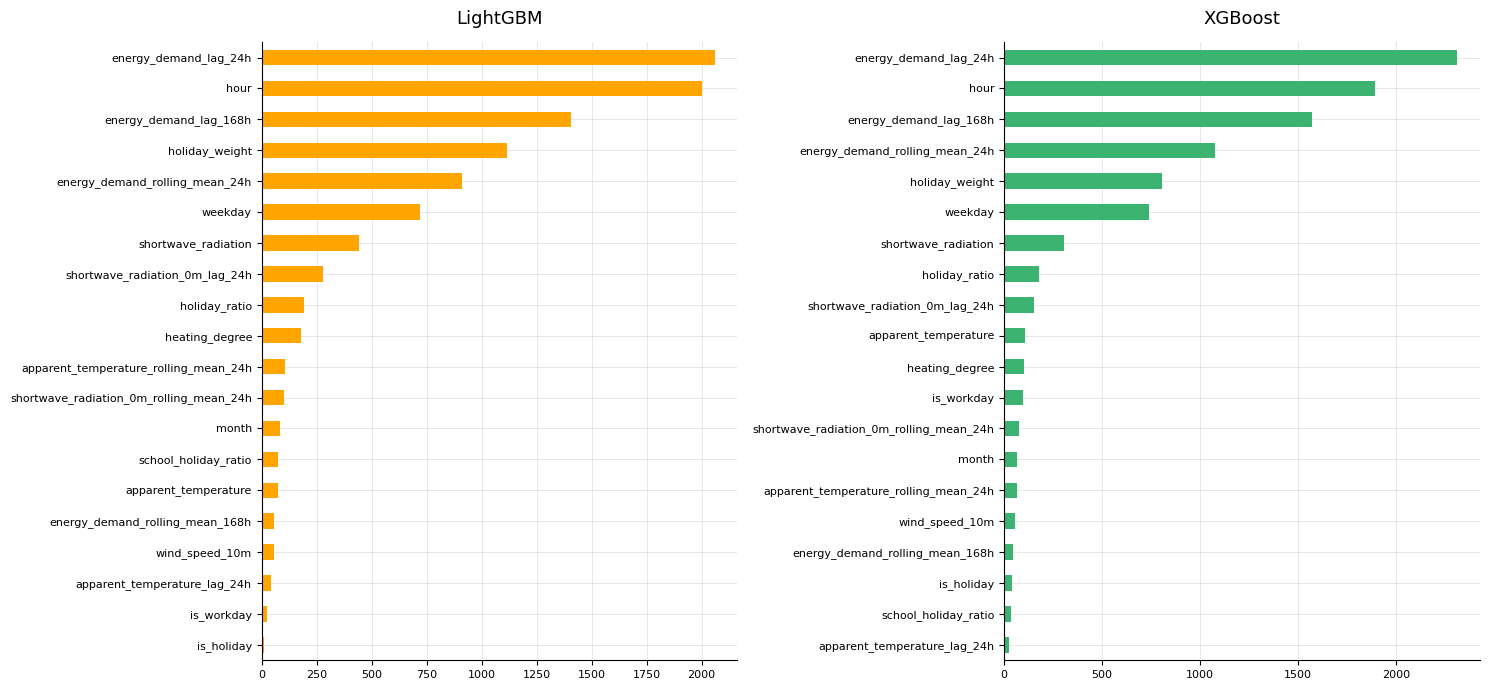

In [3]:
# plot permutation feature importance of three selected models of top 20 features for MAE
from sklearn.inspection import permutation_importance

perm_importance_mae_lgbm = permutation_importance(best_lgbm_model_bayesian, features_test, target_test, scoring='neg_mean_absolute_error')
perm_importance_mae_xgb = permutation_importance(best_xgb_model_bayesian, features_test, target_test, scoring='neg_mean_absolute_error')

perm_importances_mae_lgbm = pd.Series(perm_importance_mae_lgbm.importances_mean, index=best_lgbm_model_bayesian.feature_names_in_).sort_values(ascending=True).tail(20)
perm_importances_mae_xgb = pd.Series(perm_importance_mae_xgb.importances_mean, index=best_xgb_model_bayesian.feature_names_in_).sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
perm_importances_mae_lgbm.plot.barh(ax=axes[0], color='orange')
axes[0].set_title("LightGBM")
perm_importances_mae_xgb.plot.barh(ax=axes[1], color='mediumseagreen')
axes[1].set_title("XGBoost")
plt.tight_layout()
plt.show()


# Ablation test for the new features

* School holidays
* School holiday ratio
* Holidays
* Holiday weight

In [ ]:
# TODO
# Ablation study for the holiday features
